## Respiratory Sound Database - EDA

In [2]:
# All imports
import os
import glob
import librosa
import numpy as np
import pandas as pd
import seaborn as sns
import librosa.display
import matplotlib.pyplot as plt

### Initial Exloration

#### Uploading Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
DATASET_PATH = "/content/drive/MyDrive/MSc_DS_2025/CMT307_Applied_Machine_Learning/Group_Project/archive/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files"

In [36]:
files = os.listdir(DATASET_PATH)

print("Total files:", len(files))
print("Sample:", files[:5])

Total files: 1840
Sample: ['160_1b4_Ar_mc_AKGC417L.txt', '160_1b3_Pr_mc_AKGC417L.wav', '160_1b3_Pl_mc_AKGC417L.txt', '160_1b4_Al_mc_AKGC417L.wav', '160_1b3_Ar_mc_AKGC417L.wav']


#### Checking File Info

In [37]:
files = os.listdir(DATASET_PATH)
wav_files = [f for f in files if f.endswith(".wav")]
txt_files = [f for f in files if f.endswith(".txt")]

print(f"Total files in folder: {len(files)}")
print(f"Number of .wav files: {len(wav_files)}")
print(f"Number of .txt files: {len(txt_files)}")
print("Sample .wav files:", wav_files[:5])
print("Sample .txt files:", txt_files[:5])

Total files in folder: 1840
Number of .wav files: 920
Number of .txt files: 920
Sample .wav files: ['160_1b3_Pr_mc_AKGC417L.wav', '160_1b4_Al_mc_AKGC417L.wav', '160_1b3_Ar_mc_AKGC417L.wav', '160_1b4_Ar_mc_AKGC417L.wav', '160_1b3_Pl_mc_AKGC417L.wav']
Sample .txt files: ['160_1b4_Ar_mc_AKGC417L.txt', '160_1b3_Pl_mc_AKGC417L.txt', '160_1b3_Lr_mc_AKGC417L.txt', '160_1b4_Al_mc_AKGC417L.txt', '160_1b3_Pr_mc_AKGC417L.txt']


### Demographic Info

#### Exploration

In [38]:
DEMOGRAPHIC_PATH = "/content/drive/MyDrive/MSc_DS_2025/CMT307_Applied_Machine_Learning/Group_Project/archive/demographic_info.txt"

col_names = ["PatientNo", "Age", "Sex", "AdultBMI", "ChildWeight", "ChildHeight"]
demographics = pd.read_csv(DEMOGRAPHIC_PATH, sep=r'\s+', header=None, names=col_names)
demographics.shape

(126, 6)

In [39]:
demographics.head()

,PatientNo,Age,Sex,AdultBMI,ChildWeight,ChildHeight
0,101,3.00,F,NaN,19.0,99.0
1,102,0.75,F,NaN,9.8,73.0
2,103,70.00,F,33.00,NaN,NaN
3,104,70.00,F,28.47,NaN,NaN
4,105,7.00,F,NaN,32.0,135.0


In [40]:
demographics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PatientNo    126 non-null    int64  
 1   Age          125 non-null    float64
 2   Sex          125 non-null    object 
 3   AdultBMI     75 non-null     float64
 4   ChildWeight  44 non-null     float64
 5   ChildHeight  42 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 6.0+ KB


In [41]:
# Missing values
print(demographics.isnull().sum())

PatientNo       0
Age             1
Sex             1
AdultBMI       51
ChildWeight    82
ChildHeight    84
dtype: int64


In [42]:
demographics.describe()

,PatientNo,Age,AdultBMI,ChildWeight,ChildHeight
count,126.000000,125.00000,75.000000,44.000000,42.000000
mean,163.500000,42.99264,27.190000,21.361136,104.652381
std,36.517119,32.20907,5.372519,17.150885,30.793128
min,101.000000,0.25000,16.500000,7.140000,64.000000
25%,132.250000,4.00000,24.150000,11.755000,81.250000
50%,163.500000,60.00000,27.400000,15.100000,99.500000
75%,194.750000,71.00000,29.185000,24.325000,117.750000
max,226.000000,93.00000,53.500000,80.000000,183.000000


#### Visualisation

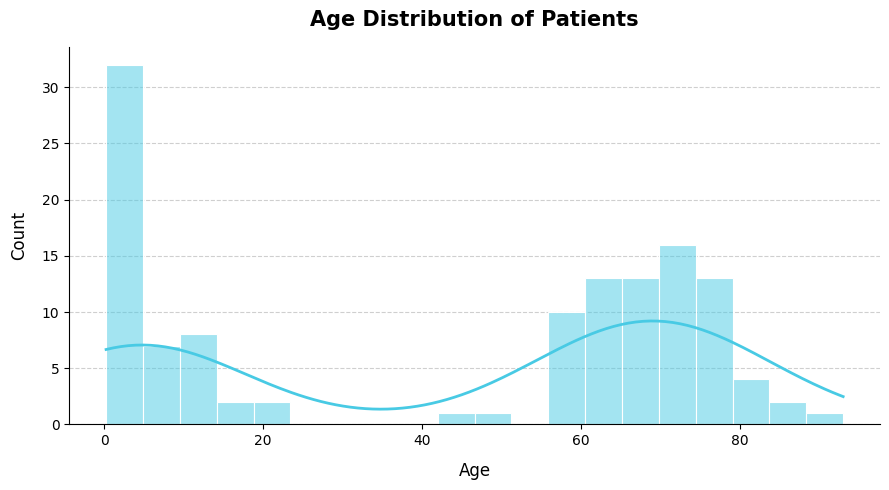

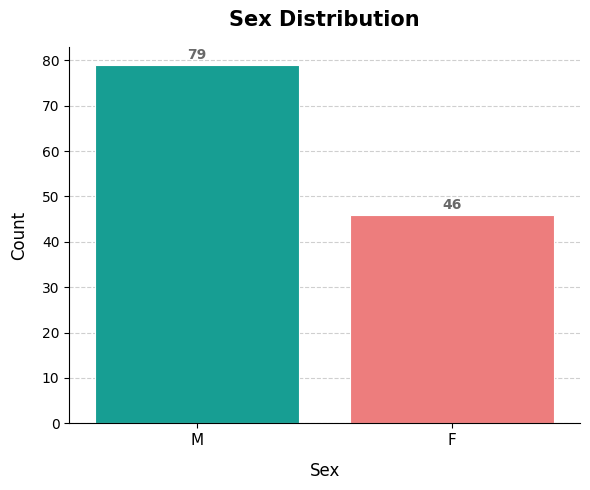

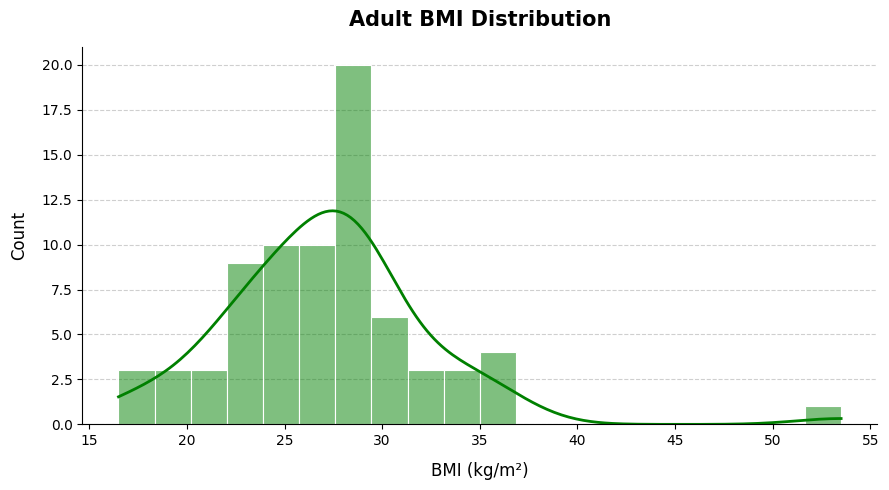

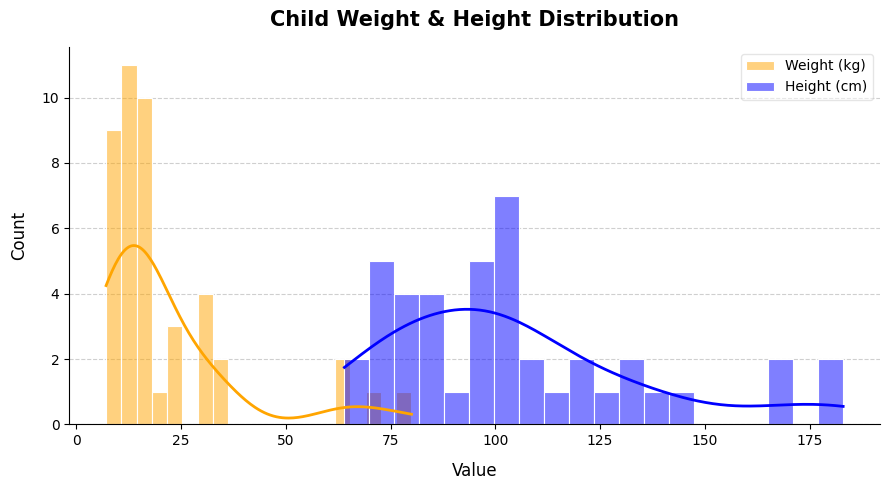

In [43]:
# Age Distribution
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(demographics['Age'], bins=20, kde=True,
             color='#48CAE4', edgecolor='white', linewidth=0.8,
             line_kws={'linewidth': 2}, ax=ax)

ax.set_title("Age Distribution of Patients", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Age", fontsize=12, labelpad=10)
ax.set_ylabel("Count", fontsize=12, labelpad=10)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# Sex Distribution
fig, ax = plt.subplots(figsize=(6, 5))

data_sex = demographics.dropna(subset=['Sex'])
order = data_sex['Sex'].value_counts().index
sns.countplot(x='Sex', hue='Sex', data=data_sex, order=order,
              palette={'M': '#00B4A6', 'F': '#FF6B6B'},
              edgecolor='white', linewidth=0.8, legend=False, ax=ax)

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{int(bar.get_height())}',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='dimgray')

ax.set_title("Sex Distribution", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Sex", fontsize=12, labelpad=10)
ax.set_ylabel("Count", fontsize=12, labelpad=10)
ax.tick_params(axis='x', labelsize=11, rotation=0)
ax.tick_params(axis='y', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# Adult BMI Distribution
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(demographics['AdultBMI'].dropna(), bins=20, kde=True,
             color='green', edgecolor='white', linewidth=0.8,
             line_kws={'linewidth': 2}, ax=ax)

ax.set_title("Adult BMI Distribution", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("BMI (kg/m²)", fontsize=12, labelpad=10)
ax.set_ylabel("Count", fontsize=12, labelpad=10)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# Child Weight & Height Distribution
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(demographics['ChildWeight'].dropna(), bins=20, kde=True,
             color='orange', edgecolor='white', linewidth=0.8,
             line_kws={'linewidth': 2}, label='Weight (kg)', ax=ax)

sns.histplot(demographics['ChildHeight'].dropna(), bins=20, kde=True,
             color='blue', edgecolor='white', linewidth=0.8,
             line_kws={'linewidth': 2}, label='Height (cm)', ax=ax)

ax.set_title("Child Weight & Height Distribution", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Value", fontsize=12, labelpad=10)
ax.set_ylabel("Count", fontsize=12, labelpad=10)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
ax.legend(fontsize=10, framealpha=0.5)
plt.tight_layout()
plt.show()

### Patient Diagnosis

#### Exploration

In [25]:
DIAGNOSIS_PATH = "/content/drive/MyDrive/MSc_DS_2025/CMT307_Applied_Machine_Learning/Group_Project/archive/Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv"

diagnosis = pd.read_csv(DIAGNOSIS_PATH, header=None, names=["PatientNo", "Diagnosis"])
diagnosis.shape

(126, 2)

In [26]:
diagnosis.head()

,PatientNo,Diagnosis
0,101,URTI
1,102,Healthy
2,103,Asthma
3,104,COPD
4,105,URTI


In [44]:
diagnosis['Diagnosis'].value_counts()

,count
Diagnosis,
COPD,64
Healthy,26
URTI,14
Bronchiectasis,7
Bronchiolitis,6
Pneumonia,6
LRTI,2
Asthma,1


In [45]:
# Missing values
print(diagnosis.isnull().sum())

PatientNo    0
Diagnosis    0
dtype: int64


No missing values in diagnosis thereby requiring no further pre-processing

#### Visualisation

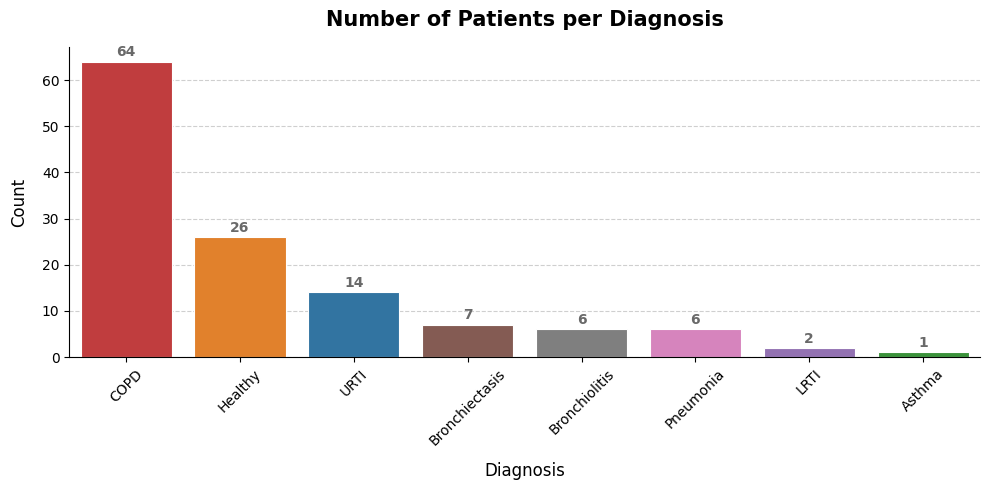

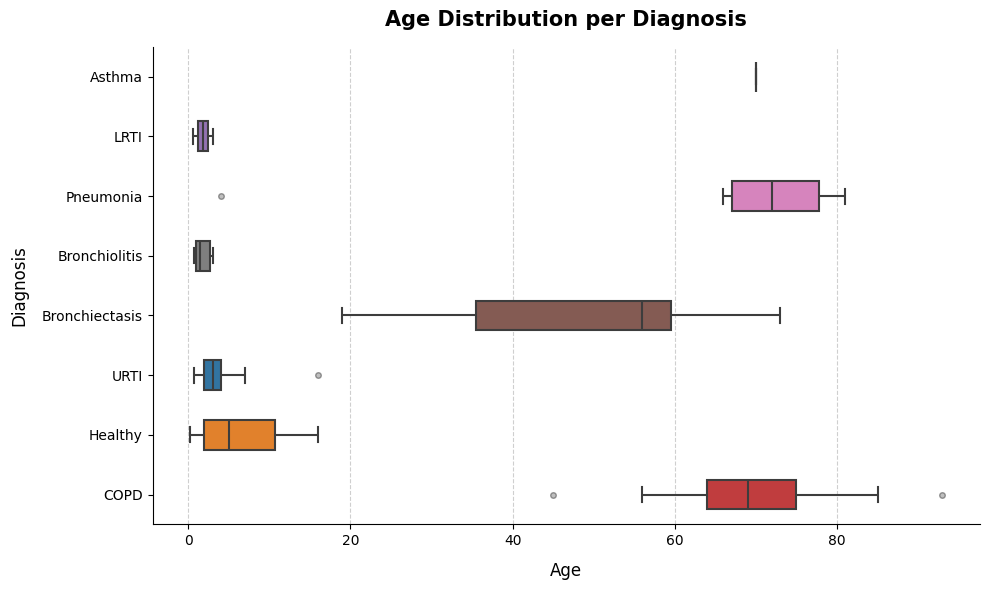

In [46]:
# Count of each diagnosis
fig, ax = plt.subplots(figsize=(10, 5))

order = diagnosis['Diagnosis'].value_counts().index
sns.countplot(x='Diagnosis', hue='Diagnosis', data=diagnosis, order=order,
              palette='tab10', edgecolor='white', linewidth=0.8, legend=False, ax=ax)

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{int(bar.get_height())}',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='dimgray')

ax.set_title("Number of Patients per Diagnosis", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Diagnosis", fontsize=12, labelpad=10)
ax.set_ylabel("Count", fontsize=12, labelpad=10)
ax.tick_params(axis='x', labelsize=10, rotation=45)
ax.tick_params(axis='y', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# Age distribution per diagnosis
merged_df = pd.merge(demographics, diagnosis, on='PatientNo')

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    y='Diagnosis',
    x='Age',
    data=merged_df,
    order=order[::-1],
    hue='Diagnosis',
    palette='tab10',
    width=0.5,
    linewidth=1.5,
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5),
    orient='h',
    legend=False,
    ax=ax
)

ax.set_title("Age Distribution per Diagnosis", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Age", fontsize=12, labelpad=10)
ax.set_ylabel("Diagnosis", fontsize=12, labelpad=10)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Annotations

#### Exploration

In [5]:
ANNOTATION_PATH = DATASET_PATH

annotation_files = glob.glob(f"{ANNOTATION_PATH}/*.txt")

annotations_list = []

for file in annotation_files:
    if file.endswith(".txt"):
        df = pd.read_csv(file, sep="\t", header=None, names=["Start", "End", "Crackles", "Wheezes"])
        df['Filename'] = os.path.basename(file)
        annotations_list.append(df)

# Combine all annotations
annotations = pd.concat(annotations_list, ignore_index=True)

In [8]:
annotations.shape

(6898, 5)

In [9]:
annotations.head()

,Start,End,Crackles,Wheezes,Filename
0,1.962,6.553,0,1,160_1b4_Ar_mc_AKGC417L.txt
1,6.553,11.160,0,1,160_1b4_Ar_mc_AKGC417L.txt
2,11.160,15.401,1,1,160_1b4_Ar_mc_AKGC417L.txt
3,15.401,19.841,1,1,160_1b4_Ar_mc_AKGC417L.txt
4,1.862,5.718,0,1,160_1b3_Pl_mc_AKGC417L.txt


In [10]:
annotations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6898 entries, 0 to 6897
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Start     6898 non-null   float64
 1   End       6898 non-null   float64
 2   Crackles  6898 non-null   int64  
 3   Wheezes   6898 non-null   int64  
 4   Filename  6898 non-null   object 
dtypes: float64(2), int64(2), object(1)
memory usage: 269.6+ KB


In [47]:
# Missing values
print(annotations.isnull().sum())

Start             0
End               0
Crackles          0
Wheezes           0
Filename          0
Duration          0
PatientNo         0
RecordingIndex    0
ChestLocation     0
Mode              0
Equipment         0
SoundType         0
dtype: int64


In [48]:
annotations[['Start', 'End']].describe()

,Start,End
count,6898.000000,6898.000000
mean,10.680312,13.380821
std,9.871169,10.032744
min,0.000000,0.250000
25%,4.042000,6.820250
50%,9.336000,12.125000
75%,14.826250,17.671000
max,84.365000,86.200000


In [12]:
# Unique values for crackles/wheezes
print("Crackles:", annotations['Crackles'].unique())
print("Wheezes:", annotations['Wheezes'].unique())

Crackles: [0 1]
Wheezes: [1 0]


In [13]:
# Count cycles per recording
cycles_per_file = annotations['Filename'].value_counts()
print("Top 5 recordings by number of cycles:\n", cycles_per_file.head())

Top 5 recordings by number of cycles:
 Filename
120_1b1_Lr_sc_Meditron.txt    33
120_1b1_Pl_sc_Meditron.txt    30
166_1p1_Ll_sc_Meditron.txt    25
166_1p1_Ar_sc_Meditron.txt    25
166_1p1_Pr_sc_Meditron.txt    24
Name: count, dtype: int64


In [14]:
# Check for negative or zero duration cycles
annotations['Duration'] = annotations['End'] - annotations['Start']
invalid_durations = annotations[annotations['Duration'] <= 0]
print("Number of invalid/zero duration cycles:", len(invalid_durations))

Number of invalid/zero duration cycles: 0


In [15]:
# Check filename format
invalid_filenames = [f for f in annotations['Filename'].unique() if len(f.split('_')) != 5]
print("Files with unexpected format:", invalid_filenames)

Files with unexpected format: []


#### Visualisation

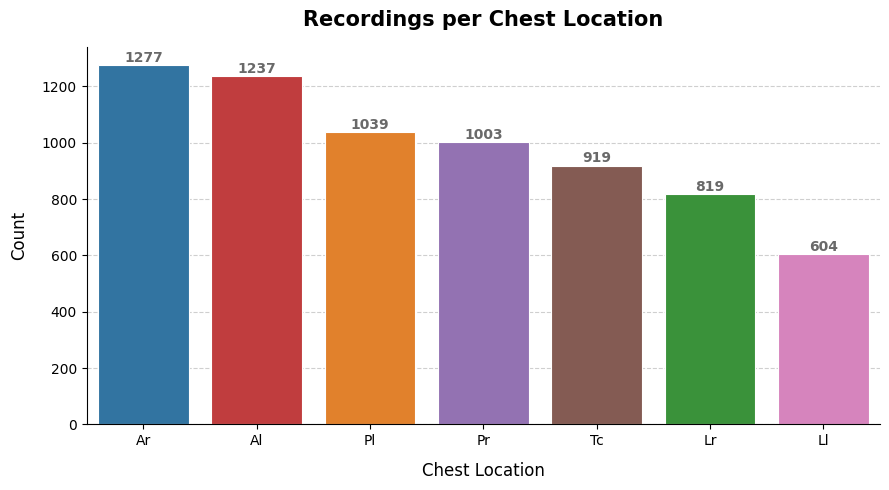

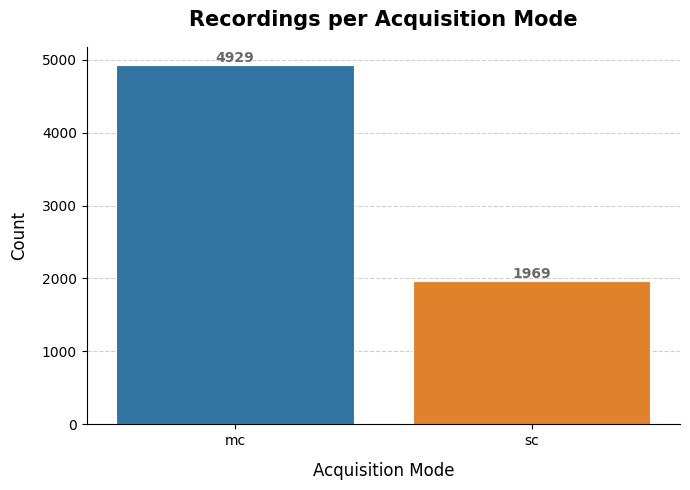

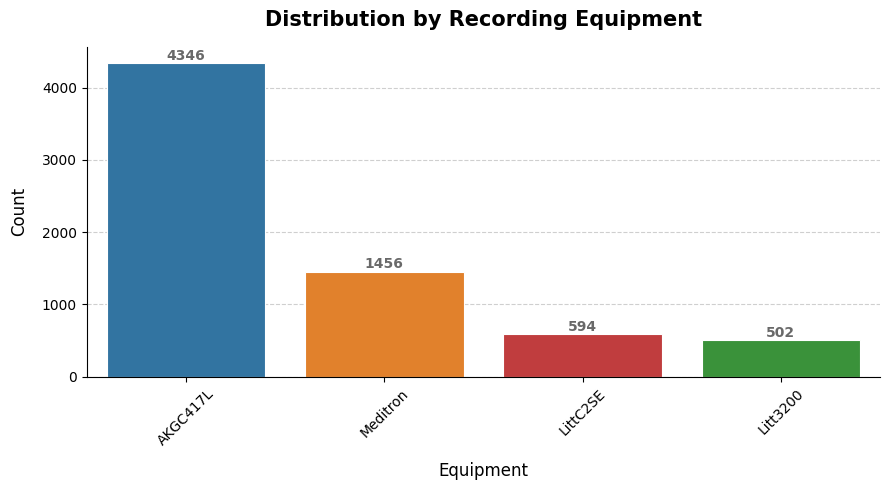

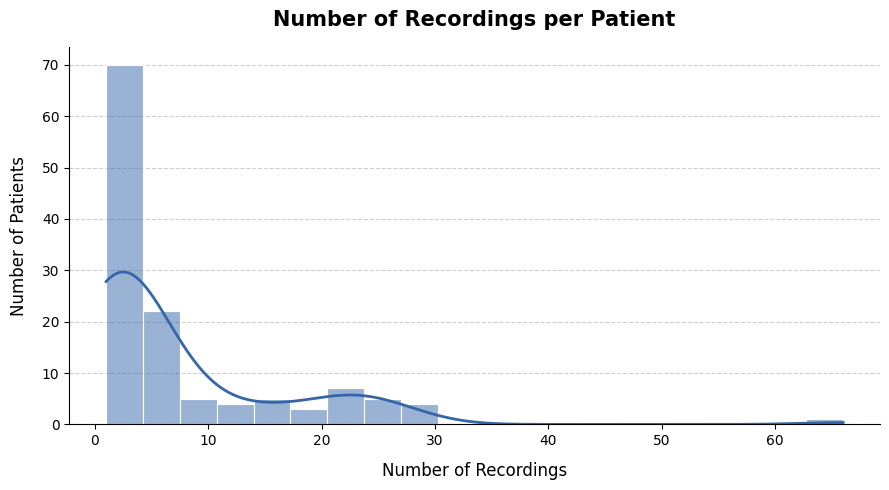

In [16]:
# Parse filenames
annotations[['PatientNo', 'RecordingIndex', 'ChestLocation', 'Mode', 'Equipment']] = annotations['Filename'].str.replace('.txt','').str.split('_', expand=True)

# Recordings per Chest Location
fig, ax = plt.subplots(figsize=(9, 5))

order = annotations['ChestLocation'].value_counts().index
sns.countplot(x='ChestLocation', hue='ChestLocation', data=annotations, order=order,
              palette='tab10', edgecolor='white', linewidth=0.8, legend=False, ax=ax)

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{int(bar.get_height())}',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='dimgray')

ax.set_title("Recordings per Chest Location", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Chest Location", fontsize=12, labelpad=10)
ax.set_ylabel("Count", fontsize=12, labelpad=10)
ax.tick_params(axis='x', labelsize=10, rotation=0)
ax.tick_params(axis='y', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# Recordings per Acquisition Mode
fig, ax = plt.subplots(figsize=(7, 5))

order = annotations['Mode'].value_counts().index
sns.countplot(x='Mode', hue='Mode', data=annotations, order=order,
              palette='tab10', edgecolor='white', linewidth=0.8, legend=False, ax=ax)

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{int(bar.get_height())}',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='dimgray')

ax.set_title("Recordings per Acquisition Mode", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Acquisition Mode", fontsize=12, labelpad=10)
ax.set_ylabel("Count", fontsize=12, labelpad=10)
ax.tick_params(axis='x', labelsize=10, rotation=0)
ax.tick_params(axis='y', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# Distribution by Recording Equipment
fig, ax = plt.subplots(figsize=(9, 5))

order = annotations['Equipment'].value_counts().index
sns.countplot(x='Equipment', hue='Equipment', data=annotations, order=order,
              palette='tab10', edgecolor='white', linewidth=0.8, legend=False, ax=ax)

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{int(bar.get_height())}',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='dimgray')

ax.set_title("Distribution by Recording Equipment", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Equipment", fontsize=12, labelpad=10)
ax.set_ylabel("Count", fontsize=12, labelpad=10)
ax.tick_params(axis='x', labelsize=10, rotation=45)
ax.tick_params(axis='y', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# Recordings per Patient
recordings_per_patient = annotations.groupby('PatientNo')['Filename'].nunique()

fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(recordings_per_patient, bins=20, kde=True,
             color='#3666A8', edgecolor='white', linewidth=0.8,
             line_kws={'linewidth': 2}, ax=ax)

ax.set_title("Number of Recordings per Patient", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Number of Recordings", fontsize=12, labelpad=10)
ax.set_ylabel("Number of Patients", fontsize=12, labelpad=10)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

Further insight for crackles & wheezes

In [17]:
# Count crackles
print(annotations['Crackles'].value_counts())

# Count wheezes
print(annotations['Wheezes'].value_counts())

Crackles
0    4528
1    2370
Name: count, dtype: int64
Wheezes
0    5506
1    1392
Name: count, dtype: int64


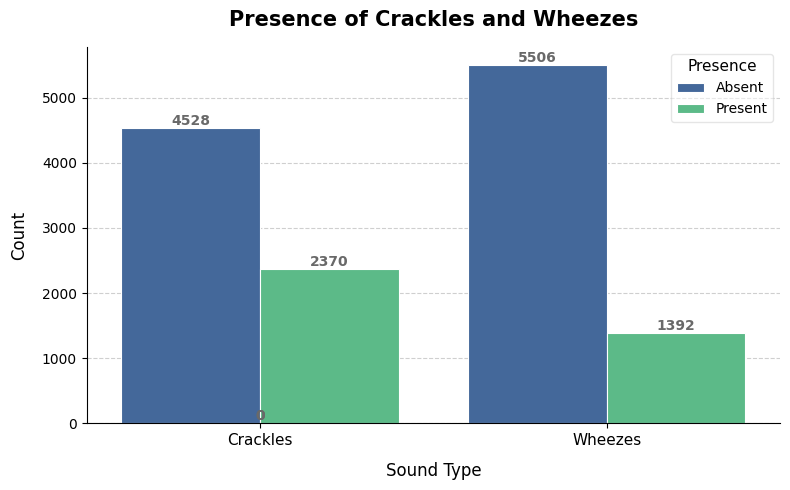

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

melted = annotations.melt(
    id_vars=['Filename'],
    value_vars=['Crackles', 'Wheezes'],
    var_name='SoundType',
    value_name='Presence'
)
melted['Presence'] = melted['Presence'].map({0: 'Absent', 1: 'Present'})

sns.countplot(
    data=melted,
    x='SoundType',
    hue='Presence',
    palette={'Present': '#4DC987', 'Absent': '#3666A8'},
    edgecolor='white',
    linewidth=0.8,
    ax=ax
)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{int(bar.get_height())}',
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='dimgray'
    )

ax.set_title("Presence of Crackles and Wheezes", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Sound Type", fontsize=12, labelpad=10)
ax.set_ylabel("Count", fontsize=12, labelpad=10)
ax.tick_params(axis='x', labelsize=11, rotation=0)
ax.tick_params(axis='y', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
ax.legend(title='Presence', title_fontsize=11, fontsize=10, framealpha=0.5)

plt.tight_layout()
plt.show()

In [19]:
def classify_sound(row):
    if row['Crackles'] == 0 and row['Wheezes'] == 0:
        return "None"
    elif row['Crackles'] == 1 and row['Wheezes'] == 0:
        return "Crackles"
    elif row['Crackles'] == 0 and row['Wheezes'] == 1:
        return "Wheezes"
    else:
        return "Both"

annotations['SoundType'] = annotations.apply(classify_sound, axis=1)

print(annotations['SoundType'].value_counts())

SoundType
None        3642
Crackles    1864
Wheezes      886
Both         506
Name: count, dtype: int64


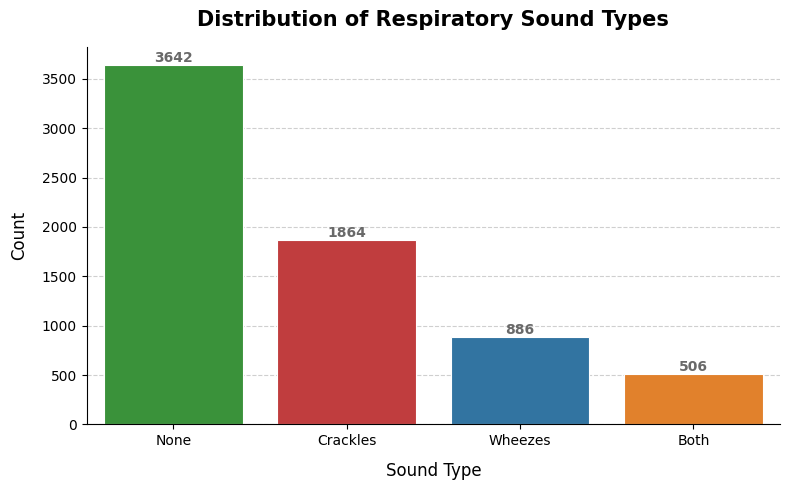

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

order = annotations['SoundType'].value_counts().index
counts = annotations['SoundType'].value_counts()

sns.countplot(
    x='SoundType',
    hue='SoundType',
    data=annotations,
    order=order,
    palette='tab10',
    edgecolor='white',
    linewidth=0.8,
    legend=False,
    ax=ax
)
# Add count labels on top of each bar
for i, bar in enumerate(ax.patches):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{int(bar.get_height())}',
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='dimgray'
    )

ax.set_title("Distribution of Respiratory Sound Types", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Sound Type", fontsize=12, labelpad=10)
ax.set_ylabel("Count", fontsize=12, labelpad=10)
ax.tick_params(axis='x', labelsize=10, rotation=0)
ax.tick_params(axis='y', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [21]:
print(annotations.columns.tolist())

['Start', 'End', 'Crackles', 'Wheezes', 'Filename', 'Duration', 'PatientNo', 'RecordingIndex', 'ChestLocation', 'Mode', 'Equipment', 'SoundType']


### Combined Insights

In [27]:
annotations['PatientNo'] = annotations['PatientNo'].astype(int)
diagnosis['PatientNo'] = diagnosis['PatientNo'].astype(int)
demographics['PatientNo'] = demographics['PatientNo'].astype(int)

In [28]:
# Merge annotations with diagnosis
merged = pd.merge(annotations, diagnosis, left_on='PatientNo', right_on='PatientNo')

# Merge with demographics
merged = pd.merge(merged, demographics, left_on='PatientNo', right_on='PatientNo')

print(merged.head())
print(merged.shape)

    Start     End  Crackles  Wheezes                    Filename  Duration  \
0   1.962   6.553         0        1  160_1b4_Ar_mc_AKGC417L.txt     4.591   
1   6.553  11.160         0        1  160_1b4_Ar_mc_AKGC417L.txt     4.607   
2  11.160  15.401         1        1  160_1b4_Ar_mc_AKGC417L.txt     4.241   
3  15.401  19.841         1        1  160_1b4_Ar_mc_AKGC417L.txt     4.440   
4   1.862   5.718         0        1  160_1b3_Pl_mc_AKGC417L.txt     3.856   

   PatientNo RecordingIndex ChestLocation Mode Equipment SoundType Diagnosis  \
0        160            1b4            Ar   mc  AKGC417L   Wheezes      COPD   
1        160            1b4            Ar   mc  AKGC417L   Wheezes      COPD   
2        160            1b4            Ar   mc  AKGC417L      Both      COPD   
3        160            1b4            Ar   mc  AKGC417L      Both      COPD   
4        160            1b3            Pl   mc  AKGC417L   Wheezes      COPD   

    Age Sex  AdultBMI  ChildWeight  ChildHeight  


#### Age vs Diagnoses

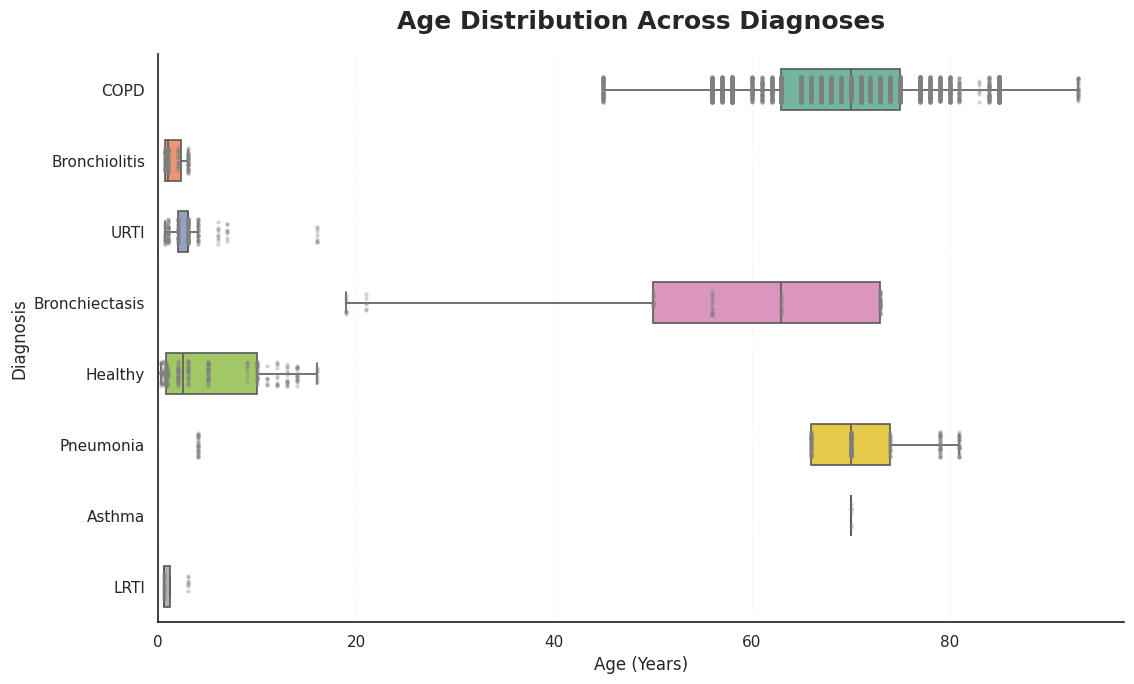

In [64]:
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(11.5,7))

sns.boxplot(
    y='Diagnosis',
    x='Age',
    hue='Diagnosis',
    data=merged,
    palette='Set2',
    dodge=False,
    width=0.58,
    linewidth=1.2,
    fliersize=0,
    legend=False,
    ax=ax
)

sns.stripplot(
    y='Diagnosis',
    x='Age',
    data=merged,
    color='gray',
    alpha=0.35,
    size=3,
    jitter=0.18,
    ax=ax
)

ax.set_title(
    "Age Distribution Across Diagnoses",
    fontsize=18,
    fontweight='bold',
    pad=18
)

ax.set_xlabel("Age (Years)", fontsize=12)
ax.set_ylabel("Diagnosis", fontsize=12)

ax.set_xlim(left=0)

ax.spines[['top', 'right']].set_visible(False)

ax.xaxis.grid(True, linestyle='--', alpha=0.15)
ax.yaxis.grid(False)

plt.tight_layout()
plt.show()

#### Gender vs Diagnoses

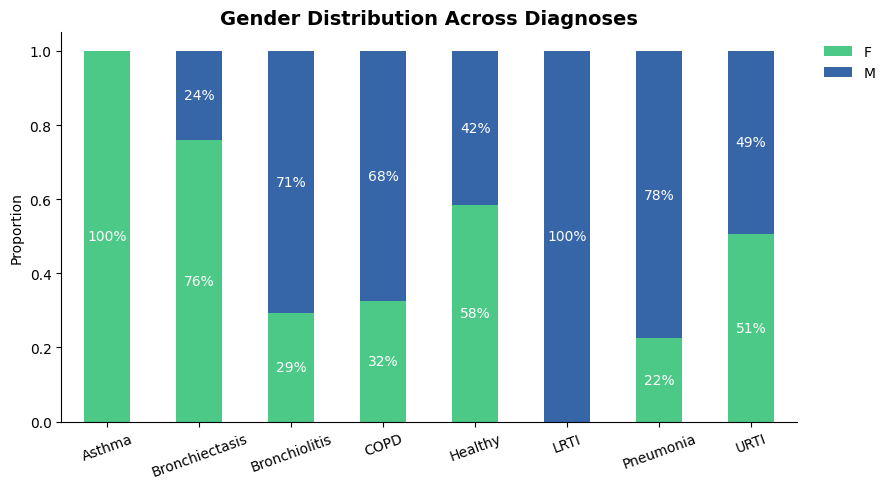

In [66]:
gender_disease = pd.crosstab(merged['Diagnosis'], merged['Sex'], normalize='index')

plt.style.use('default')
fig, ax = plt.subplots(figsize=(9,5))
colors = ['#4DC987', '#3666A8']

gender_disease.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor='none'
)

ax.grid(False)

for i, row in enumerate(gender_disease.values):
    cumulative = 0
    for val in row:
        if val > 0:
            ax.text(
                i,
                cumulative + val/2,
                f"{val*100:.0f}%",
                ha='center',
                va='center',
                fontsize=10,
                color='white'
            )
        cumulative += val

ax.set_title("Gender Distribution Across Diagnoses", fontsize=14, weight='bold')
ax.set_ylabel("Proportion")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20)

ax.legend(
    title="",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

#### Sound Types Per Diagnosis

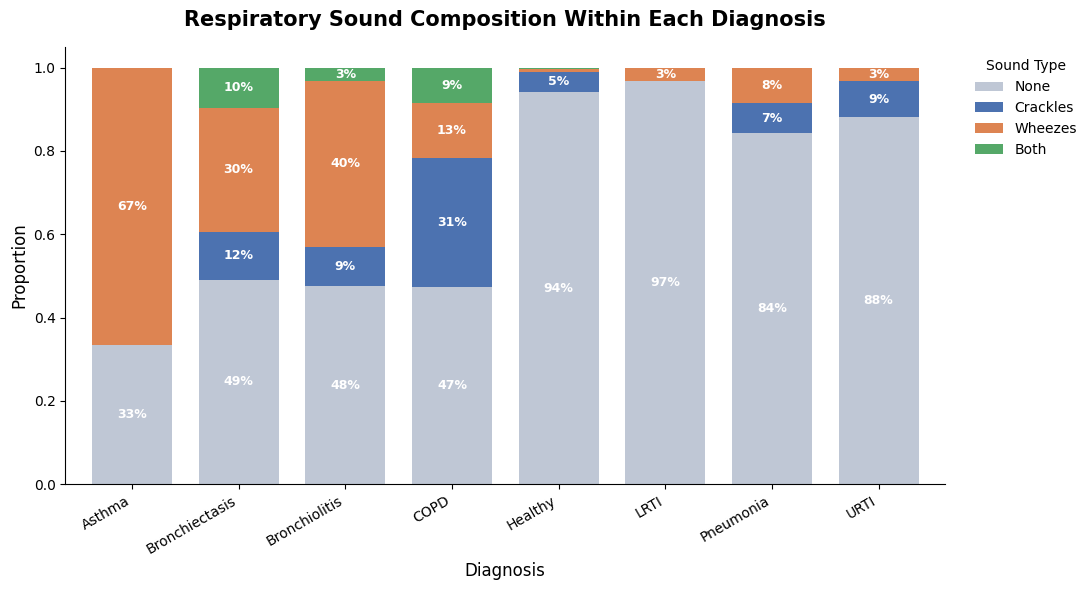

In [68]:
diag_sound = pd.crosstab(
    merged['Diagnosis'],
    merged['SoundType'],
    normalize='index'
)

preferred_cols = ['None', 'Crackles', 'Wheezes', 'Both']
diag_sound = diag_sound[[c for c in preferred_cols if c in diag_sound.columns]]

color_map = {
    'None': '#BFC7D5',
    'Crackles': '#4C72B0',
    'Wheezes': '#DD8452',
    'Both': '#55A868'
}

colors = [color_map[col] for col in diag_sound.columns]

fig, ax = plt.subplots(figsize=(11, 6))

diag_sound.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor='none',
    width=0.75
)

for i, (_, row) in enumerate(diag_sound.iterrows()):
    cumulative = 0
    for val in row:
        if val >= 0.01:
            ax.text(
                i,
                cumulative + val/2,
                f"{val*100:.0f}%",
                ha='center',
                va='center',
                fontsize=9,
                color='white',
                fontweight='bold'
            )
        cumulative += val

ax.set_title("Respiratory Sound Composition Within Each Diagnosis",
             fontsize=15, fontweight='bold', pad=15)

ax.set_xlabel("Diagnosis", fontsize=12)
ax.set_ylabel("Proportion", fontsize=12)

ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

ax.spines[['top', 'right']].set_visible(False)
ax.grid(False)

ax.legend(
    title="Sound Type",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.subplots_adjust(right=0.82)
plt.tight_layout()
plt.show()

#### Age vs Sound Type

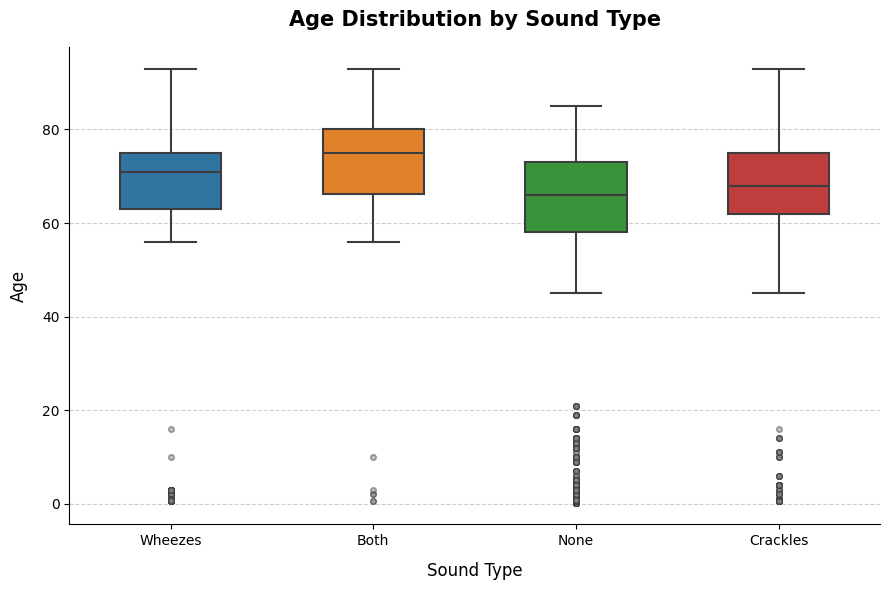

In [69]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(
    x='SoundType',
    y='Age',
    data=merged,
    hue='SoundType',
    palette='tab10',
    width=0.5,
    linewidth=1.5,
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5),
    legend=False,
    ax=ax
)

ax.set_title("Age Distribution by Sound Type", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Sound Type", fontsize=12, labelpad=10)
ax.set_ylabel("Age", fontsize=12, labelpad=10)
ax.tick_params(axis='x', labelsize=10, rotation=0)
ax.tick_params(axis='y', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

#### Chest Location vs Sound Type

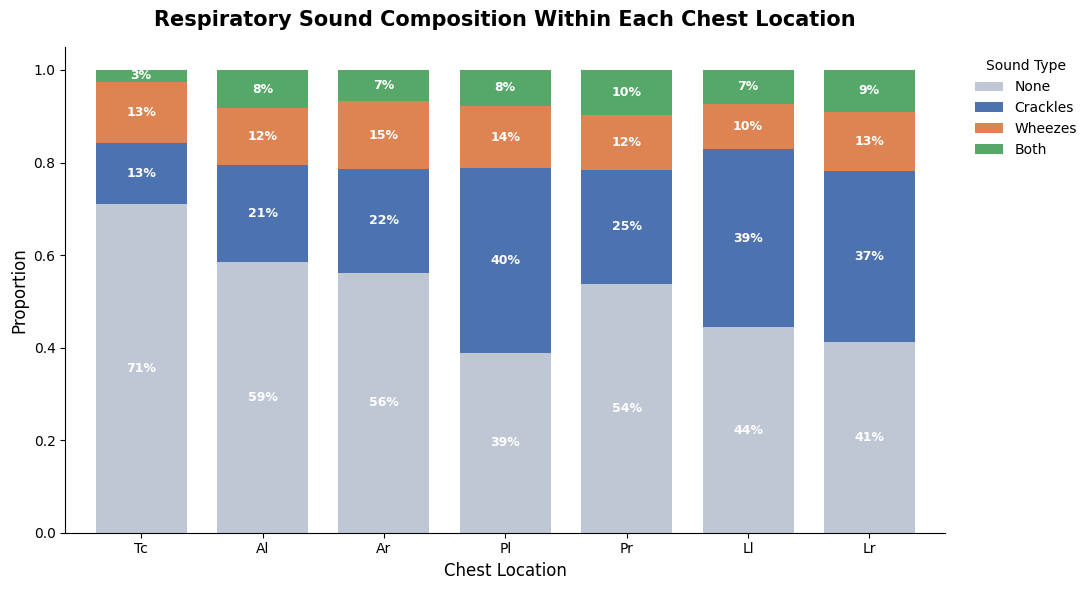

In [72]:
chest_sound = pd.crosstab(
    merged['ChestLocation'],
    merged['SoundType'],
    normalize='index'
)

preferred_cols = ['None', 'Crackles', 'Wheezes', 'Both']
chest_sound = chest_sound[[c for c in preferred_cols if c in chest_sound.columns]]

preferred_index = ['Tc', 'Al', 'Ar', 'Pl', 'Pr', 'Ll', 'Lr']
chest_sound = chest_sound.reindex(
    [idx for idx in preferred_index if idx in chest_sound.index]
)

color_map = {
    'None': '#BFC7D5',
    'Crackles': '#4C72B0',
    'Wheezes': '#DD8452',
    'Both': '#55A868'
}

colors = [color_map[col] for col in chest_sound.columns]

fig, ax = plt.subplots(figsize=(11, 6))

chest_sound.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor='none',
    width=0.75
)

for i, (_, row) in enumerate(chest_sound.iterrows()):
    cumulative = 0
    for val in row:
        if val >= 0.01:
            ax.text(
                i,
                cumulative + val/2,
                f"{val*100:.0f}%",
                ha='center',
                va='center',
                fontsize=9,
                color='white',
                fontweight='bold'
            )
        cumulative += val

ax.set_title(
    "Respiratory Sound Composition Within Each Chest Location",
    fontsize=15,
    fontweight='bold',
    pad=15
)

ax.set_xlabel("Chest Location", fontsize=12)
ax.set_ylabel("Proportion", fontsize=12)

ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

ax.spines[['top', 'right']].set_visible(False)
ax.grid(False)

ax.legend(
    title="Sound Type",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.subplots_adjust(right=0.82)
plt.tight_layout()
plt.show()

#### Diagnosis vs Chest Location

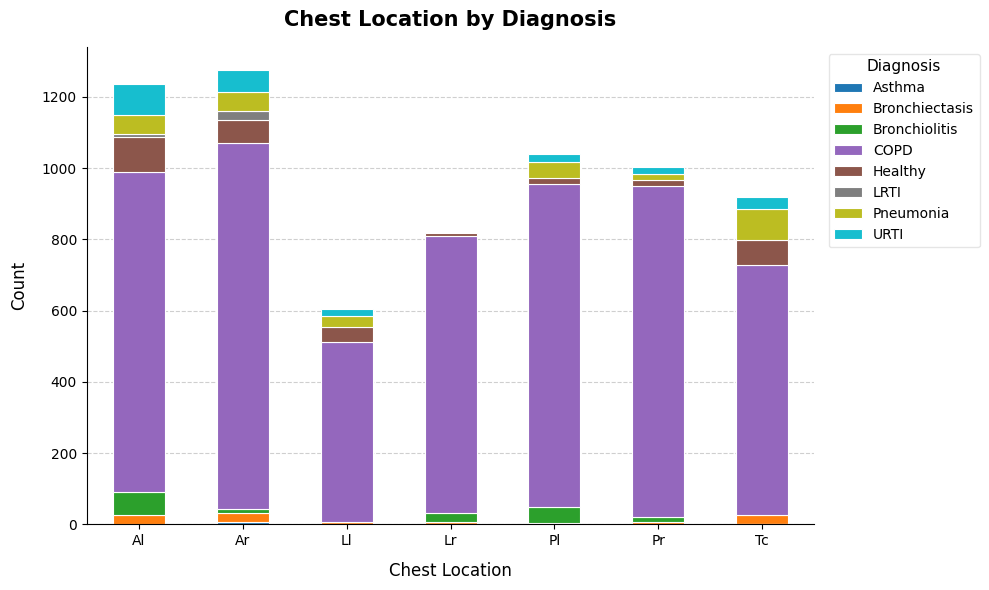

In [73]:
fig, ax = plt.subplots(figsize=(10, 6))

pivot = merged.groupby(['ChestLocation', 'Diagnosis']).size().unstack(fill_value=0)

pivot.plot(
    kind='bar',
    stacked=True,
    colormap='tab10',
    edgecolor='white',
    linewidth=0.8,
    ax=ax
)

ax.set_title("Chest Location by Diagnosis", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Chest Location", fontsize=12, labelpad=10)
ax.set_ylabel("Count", fontsize=12, labelpad=10)
ax.tick_params(axis='x', labelsize=10, rotation = 0)
ax.tick_params(axis='y', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
ax.legend(title='Diagnosis', title_fontsize=11, fontsize=10, framealpha=0.5, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### Correlation of Age, Crackles & Wheezes

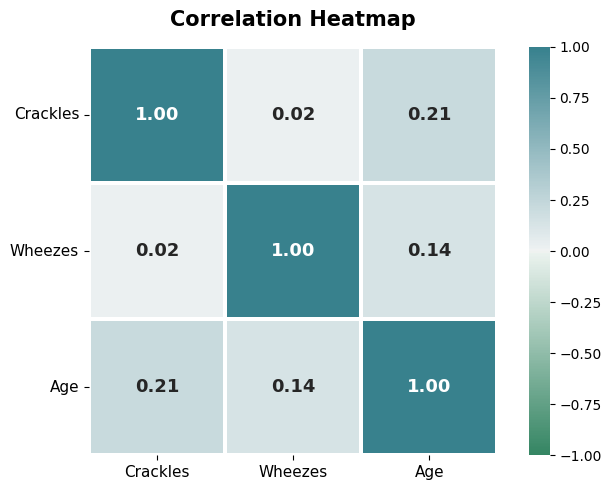

In [74]:
corr_data = merged[['Crackles', 'Wheezes', 'Age']].copy()

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    corr_data.corr(),
    annot=True,
    fmt=".2f",
    cmap=sns.diverging_palette(150, 210, s=80, l=50, as_cmap=True),
    center=0,
    square=True,
    linewidths=1.5,
    linecolor='white',
    annot_kws={"size": 13, "weight": "bold"},
    vmin=-1, vmax=1,
    ax=ax
)

ax.set_title("Correlation Heatmap", fontsize=15, fontweight='bold', pad=15)
ax.tick_params(axis='x', labelsize=11, rotation=0)
ax.tick_params(axis='y', labelsize=11, rotation=0)

plt.tight_layout()
plt.show()

### Audio Files EDA

In [101]:
!pip install librosa

In [75]:
wav_files = [f for f in os.listdir(DATASET_PATH) if f.endswith(".wav")]

sample_file = os.path.join(DATASET_PATH, wav_files[0])

print(sample_file)

/content/drive/MyDrive/MSc_DS_2025/CMT307_Applied_Machine_Learning/Group_Project/archive/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/160_1b3_Pr_mc_AKGC417L.wav


In [76]:
y, sr = librosa.load(sample_file)

print("Sampling rate:", sr)
print("Audio length:", len(y))

Sampling rate: 22050
Audio length: 441000


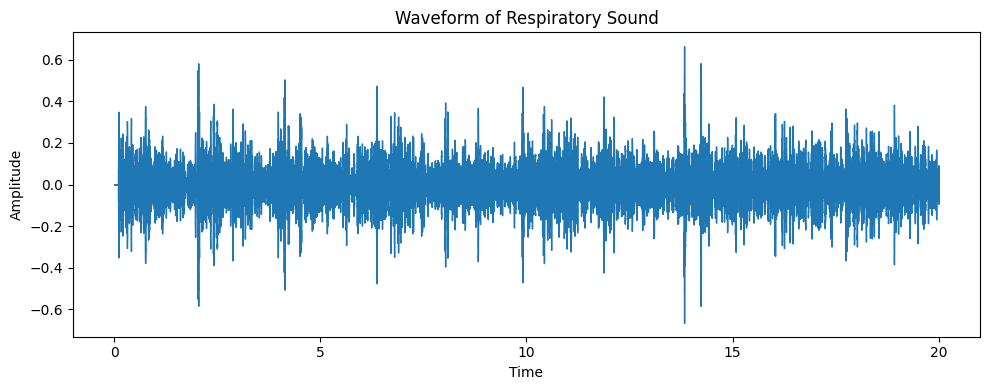

In [77]:
plt.figure(figsize=(10,4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform of Respiratory Sound")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

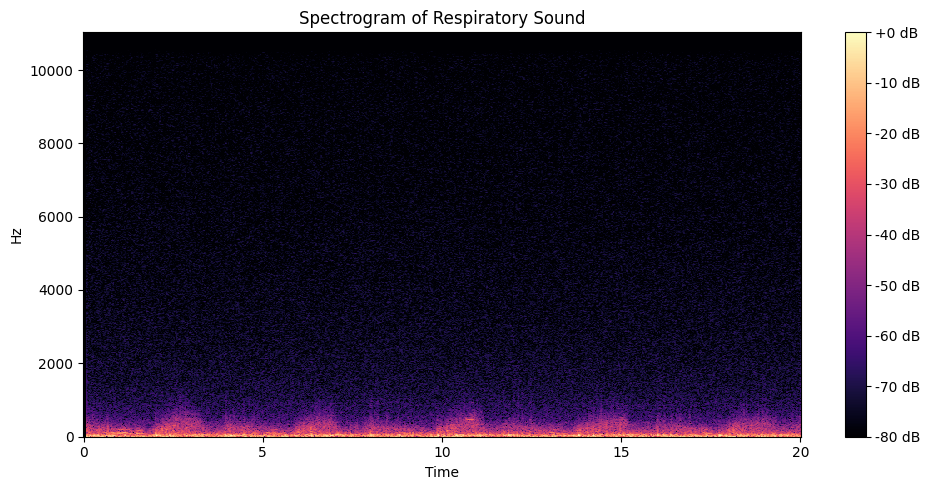

In [78]:
# Compute spectrogram
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(abs(D), ref=np.max)

plt.figure(figsize=(10,5))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram of Respiratory Sound")
plt.tight_layout()
plt.show()

#### Comparing Different Sound Types

In [79]:
# Get one filename per sound type
sample_files = annotations.groupby('SoundType')['Filename'].first()
print(sample_files)

SoundType
Both        160_1b4_Ar_mc_AKGC417L.txt
Crackles    160_1b3_Pr_mc_AKGC417L.txt
None        160_1b3_Pl_mc_AKGC417L.txt
Wheezes     160_1b4_Ar_mc_AKGC417L.txt
Name: Filename, dtype: object


In [80]:
def get_wav_path(txt_filename):
    wav_filename = txt_filename.replace(".txt", ".wav")
    return os.path.join(DATASET_PATH, wav_filename)

In [81]:
def plot_audio(file_path, title):
    y, sr = librosa.load(file_path)

    plt.figure(figsize=(14,4))

    # Waveform
    plt.subplot(1,2,1)
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"{title} - Waveform")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")

    # Mel Spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=1000)
    S_db = librosa.power_to_db(S, ref=np.max)

    plt.subplot(1,2,2)
    img = librosa.display.specshow(
        S_db,
        sr=sr,
        x_axis='time',
        y_axis='mel'
    )

    plt.colorbar(img, format='%+2.0f dB')
    plt.clim(-40, 0)
    plt.title(f"{title} - Mel Spectrogram")

    plt.tight_layout()
    plt.show()

Showing: Both


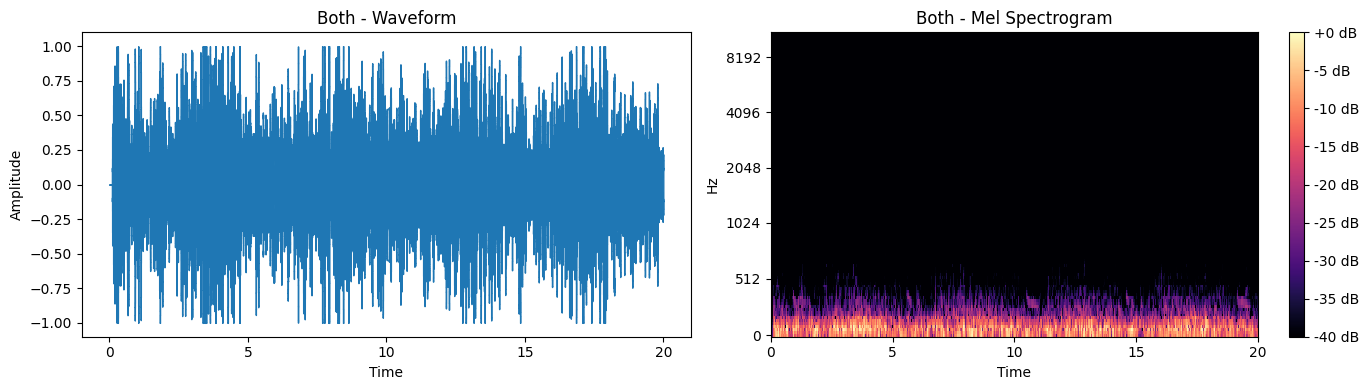

Showing: Crackles


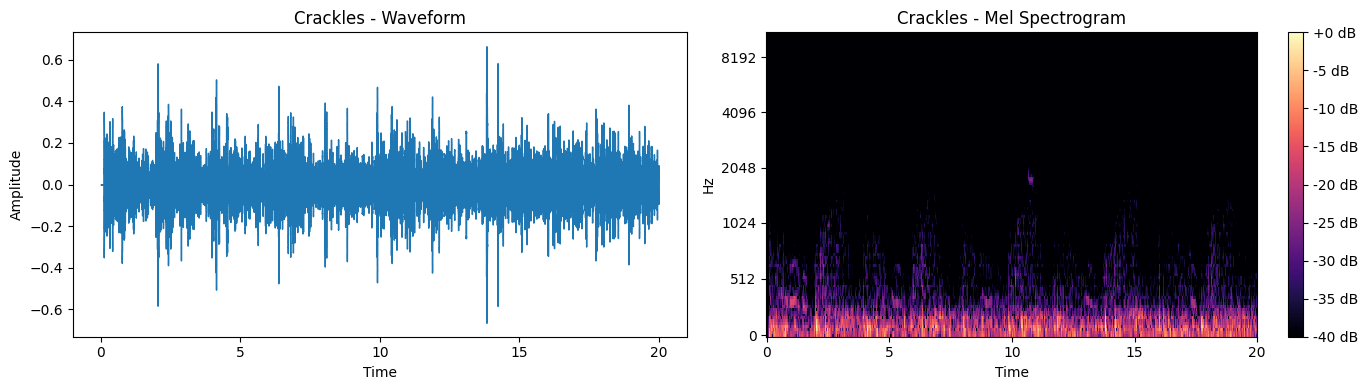

Showing: None


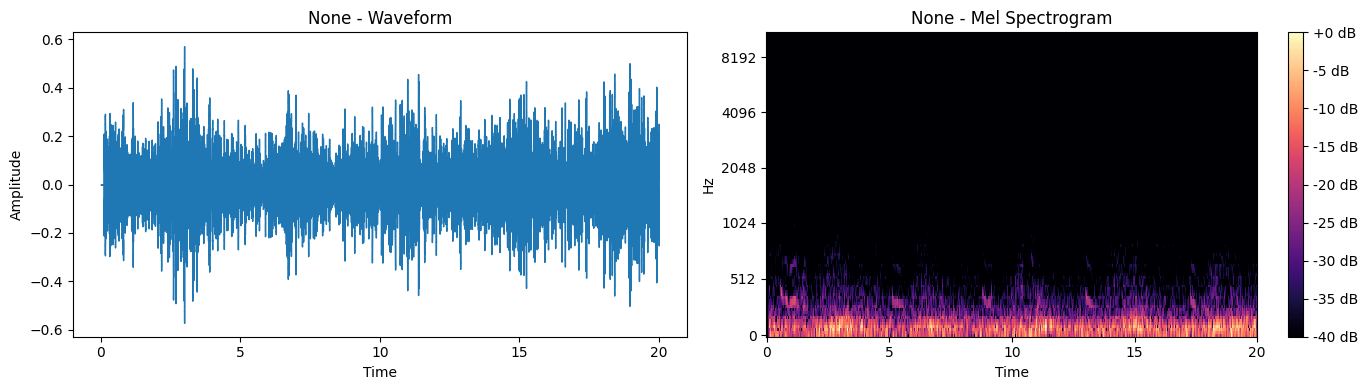

Showing: Wheezes


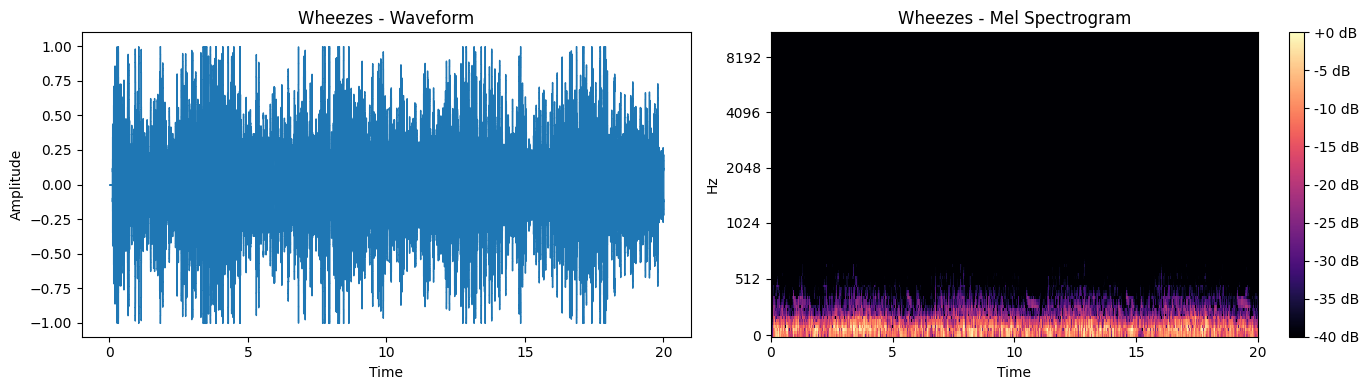

In [82]:
for sound_type, txt_file in sample_files.items():
    wav_path = get_wav_path(txt_file)
    print(f"Showing: {sound_type}")
    plot_audio(wav_path, sound_type)

Both standard and Mel spectrograms were explored. While standard spectrograms provide precise frequency information, Mel spectrograms better highlight perceptually relevant patterns such as wheezes and crackles, making them more suitable for exploratory analysis of respiratory sounds.